## Milestone 2.4: The Economic Layer
**Goal:** Pin the empirical £/MWh constraint cost proxy and calculate the financial value captured (or lost) due to IT scheduling practices.
**Applies:** Traceability Mandate, Translate to Physical Units, Fail Loudly.

## Summary & Policy Implications

**The Finding:** 
Under modern hyperscaler architectures (async checkpointing, automated orchestration), the IT notice period for flexible AI training is approximately **1.0 hour**. Because the median Scottish export constraint event lasts **2.0 hours**, the Duration Compatibility Factor is **1.0**. 

This means flexible AI siting can capture **100% of the theoretical flexibility value** for median events, turning a projected £X million annual loss (under legacy 12-hour assumptions) into a fully captured grid asset.

**The Mechanism:**
1. Modern async checkpointing writes 200GB states in ~5 minutes.
2. Automated K8s operators drain nodes and re-initialize in ~10 minutes.
3. NESO Balancing Mechanism protocols require delivery within 20 minutes.
4. Total notice required: ~1.0 hour, well within the 2.0-hour median event window.

**Scope Boundary & Caveats:**
- **Scope:** This models *transmission-level* thermal constraints at SCOTEX (B6) and SSEN-S (B2) only. It does not model distribution-level constraints.
- **Caveat 1:** This applies to median (P50) and long (P90) events. Sub-1-hour grid events (P10) remain physically incompatible with *any* large-scale load response, AI or otherwise.
- **Caveat 2:** The "1.0 hour" notice period assumes developers actively implement modern async stacks. Legacy, monolithic training loops will still suffer the 83% value loss.
- **Caveat 3:** This models constraint-event revenue only. It does not include capacity market revenue, private-wire arbitrage, or co-located battery storage interactions (deferred to Stage 3).

In [1]:
import sys
from pathlib import Path
import polars as pl
import requests
import yaml
from datetime import datetime

def find_project_root() -> Path:
    """Walk up from cwd until we find pyproject.toml (the project sentinel)."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError(
        f"Could not find project root (no pyproject.toml found).\n"
        f"Searched from: {current}\n"
        f"Run `uv run jupyter lab` from the project root, not from notebooks/."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
CONFIGS_DIR = PROJECT_ROOT / "configs"

# Verify Python executable is from the project venv (Manifesto §4.1)
venv_python = Path(sys.executable)
assert "scotland-ai-split-zones" in str(venv_python), (
    f"Wrong Python executable: {venv_python}\n"
    f"Run notebooks via `uv run jupyter lab` from the project root."
)

print(f"✅ Project root: {PROJECT_ROOT}")
print(f"✅ Python:        {venv_python}")
print(f"✅ Data dir:      {DATA_DIR}")
print(f"✅ Configs dir:   {CONFIGS_DIR}")

✅ Project root: /home/ndrew/scotland-ai-split-zones
✅ Python:        /home/ndrew/scotland-ai-split-zones/.venv/bin/python3
✅ Data dir:      /home/ndrew/scotland-ai-split-zones/data
✅ Configs dir:   /home/ndrew/scotland-ai-split-zones/configs


In [2]:
# ==============================================================================
# CONFIGURATION (No magic numbers)
# ==============================================================================
API_URL = "https://api.neso.energy/api/3/action/datastore_search"
TIMEOUT = (5, 10)  # Fail loudly on network hangs

# Resource ID for Thermal Constraint Costs 23-24 (verified in CKAN discovery)
COST_RESOURCE_ID = "75c9c564-af38-4421-a461-a612a6921212"

# Target boundaries (Precise NESO terminology)
TARGET_BOUNDARIES = ["SCOTEX", "SSEN-S"]

# Empirical volumes from Milestone 2.2 (Total constraint volume where Flow > Limit)
VOLUMES_MWH = {
    "SCOTEX": 13246610.0,
    "SSEN-S": 9531322.0
}
TOTAL_VOLUME_MWH = sum(VOLUMES_MWH.values())

# Duration Compatibility Factors from Milestone 2.3 (Median 2.0h event)
COMPATIBILITY_MODERN = 1.00   # Current state with async checkpointing (~1.0h notice)
COMPATIBILITY_LEGACY = 0.17   # Legacy conservative estimate (12.0h notice)

In [3]:
print("Fetching Thermal Constraint Costs (23-24) from NESO CKAN...")

params = {
    "resource_id": COST_RESOURCE_ID,
    "limit": 5000  # Safe limit for ~2190 rows (365 days * 6 boundaries)
}

resp = requests.get(API_URL, params=params, timeout=TIMEOUT)
resp.raise_for_status()
data = resp.json()

if not data.get("success"):
    raise RuntimeError(f"API returned success=false: {data.get('error')}")

records = data["result"]["records"]
if not records:
    raise RuntimeError("No records returned from CKAN. Check resource ID.")

df = pl.DataFrame(records)

# Validate schema (Fail Loudly)
required_cols = ["Constraint Group", "Daily Cost (GBP)"]
for col in required_cols:
    if col not in df.columns:
        raise RuntimeError(f"Missing required column: '{col}'. Available: {df.columns}")

print(f"✅ Fetched {len(df)} rows. Schema validated.")

Fetching Thermal Constraint Costs (23-24) from NESO CKAN...
✅ Fetched 2196 rows. Schema validated.


In [4]:
print("\nFiltering for target boundaries: SCOTEX, SSEN-S...")

# Filter and cast
cost_df = df.filter(pl.col("Constraint Group").is_in(TARGET_BOUNDARIES))
cost_df = cost_df.with_columns(pl.col("Daily Cost (GBP)").cast(pl.Float64, strict=False))

# Aggregate total cost (Polars returns native float, no .item() needed)
total_cost_gbp = cost_df.select(pl.col("Daily Cost (GBP)").sum()).to_series()[0]

print(f"✅ Total Annual Constraint Cost (SCOTEX + SSEN-S, 23-24): £{total_cost_gbp:,.0f}")
print(f"✅ Total Annual Constraint Volume (SCOTEX + SSEN-S, 23-24): {TOTAL_VOLUME_MWH:,.0f} MWh")

# Calculate empirical £/MWh proxy
empirical_gbp_per_mwh = total_cost_gbp / TOTAL_VOLUME_MWH
print(f"\n📌 EMPIRICAL CONSTRAINT COST PROXY: £{empirical_gbp_per_mwh:,.2f} / MWh")
print("   (Derived from boundary-specific NESO Thermal Constraint Costs / Volumes)")

# Calculate financial impact of scheduling practices
# Value Captured = Volume × Compatibility Factor × £/MWh
# Value Lost = Volume × (1 - Compatibility Factor) × £/MWh

value_captured_modern = TOTAL_VOLUME_MWH * COMPATIBILITY_MODERN * empirical_gbp_per_mwh
value_lost_legacy = TOTAL_VOLUME_MWH * (1.0 - COMPATIBILITY_LEGACY) * empirical_gbp_per_mwh

print("\n" + "-" * 80)
print("FINANCIAL IMPACT OF IT SCHEDULING PRACTICES (Median 2.0h Event)")
print("-" * 80)
print(f"• MODERN PRACTICE (~1.0h notice, factor = {COMPATIBILITY_MODERN:.2f}):")
print(f"  → Value Captured: £{value_captured_modern:,.0f} / year")
print(f"  → Value Lost: £0 / year (event fully utilised)")
print(f"\n• LEGACY PRACTICE (12.0h notice, factor = {COMPATIBILITY_LEGACY:.2f}):")
print(f"  → Value Captured: £{TOTAL_VOLUME_MWH * COMPATIBILITY_LEGACY * empirical_gbp_per_mwh:,.0f} / year")
print(f"  → Value Lost: £{value_lost_legacy:,.0f} / year (83% of potential value wasted)")


Filtering for target boundaries: SCOTEX, SSEN-S...
✅ Total Annual Constraint Cost (SCOTEX + SSEN-S, 23-24): £73,915,860
✅ Total Annual Constraint Volume (SCOTEX + SSEN-S, 23-24): 22,777,932 MWh

📌 EMPIRICAL CONSTRAINT COST PROXY: £3.25 / MWh
   (Derived from boundary-specific NESO Thermal Constraint Costs / Volumes)

--------------------------------------------------------------------------------
FINANCIAL IMPACT OF IT SCHEDULING PRACTICES (Median 2.0h Event)
--------------------------------------------------------------------------------
• MODERN PRACTICE (~1.0h notice, factor = 1.00):
  → Value Captured: £73,915,860 / year
  → Value Lost: £0 / year (event fully utilised)

• LEGACY PRACTICE (12.0h notice, factor = 0.17):
  → Value Captured: £12,565,696 / year
  → Value Lost: £61,350,164 / year (83% of potential value wasted)


In [5]:
CONFIGS_DIR.mkdir(parents=True, exist_ok=True)

proxy_data = {
    "curtailment_value_proxy": {
        "source_name": "NESO Thermal Constraint Costs Data 23-24 & Day Ahead Constraint Flows",
        "publication_year": 2024,
        "geography": "Scotland (SCOTEX B6, SSEN-S B2)",
        "value_gbp_per_mwh": round(empirical_gbp_per_mwh, 2),
        "value_type": "Empirical boundary-specific thermal constraint cost",
        "notes": (
            f"Calculated as Total Cost (£{total_cost_gbp:,.0f}) / "
            f"Total Volume ({TOTAL_VOLUME_MWH:,.0f} MWh). "
            f"Under modern IT practices (~1.0h notice), the compatibility factor is "
            f"{COMPATIBILITY_MODERN}, capturing £{value_captured_modern:,.0f} in value. "
            f"Under legacy practices (12.0h notice), the factor drops to {COMPATIBILITY_LEGACY}, "
            f"losing £{value_lost_legacy:,.0f} in value."
        ),
        "pinned_timestamp": datetime.now().strftime("%Y-%m-%d")
    }
}

config_path = CONFIGS_DIR / "curtailment_value_proxy.yml"
with open(config_path, "w") as f:
    yaml.dump(proxy_data, f, default_flow_style=False, sort_keys=False)

print(f"\n✅ Proxy successfully pinned and saved to: {config_path}")


✅ Proxy successfully pinned and saved to: /home/ndrew/scotland-ai-split-zones/configs/curtailment_value_proxy.yml


In [8]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from pathlib import Path

# ==============================================================================
# DIRECTORY SETUP (Fail Loudly: Ensure output directory exists)
# ==============================================================================
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Set Tufte-compliant style
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 150

# ==============================================================================
# DATA CONSTANTS (from Milestone 2.4)
# ==============================================================================
total_cost_gbp = 73915860
value_lost_legacy = 61350164
value_captured_modern = 73915860
value_captured_legacy = 12565696
empirical_gbp_per_mwh = 3.25
compatibility_modern = 1.0
compatibility_legacy = 0.17
total_volume_mwh = 22777932

print(f"✅ Setup complete. Figures will be saved to: {FIGURES_DIR.absolute()}/")

✅ Setup complete. Figures will be saved to: /home/ndrew/scotland-ai-split-zones/notebooks/figures/


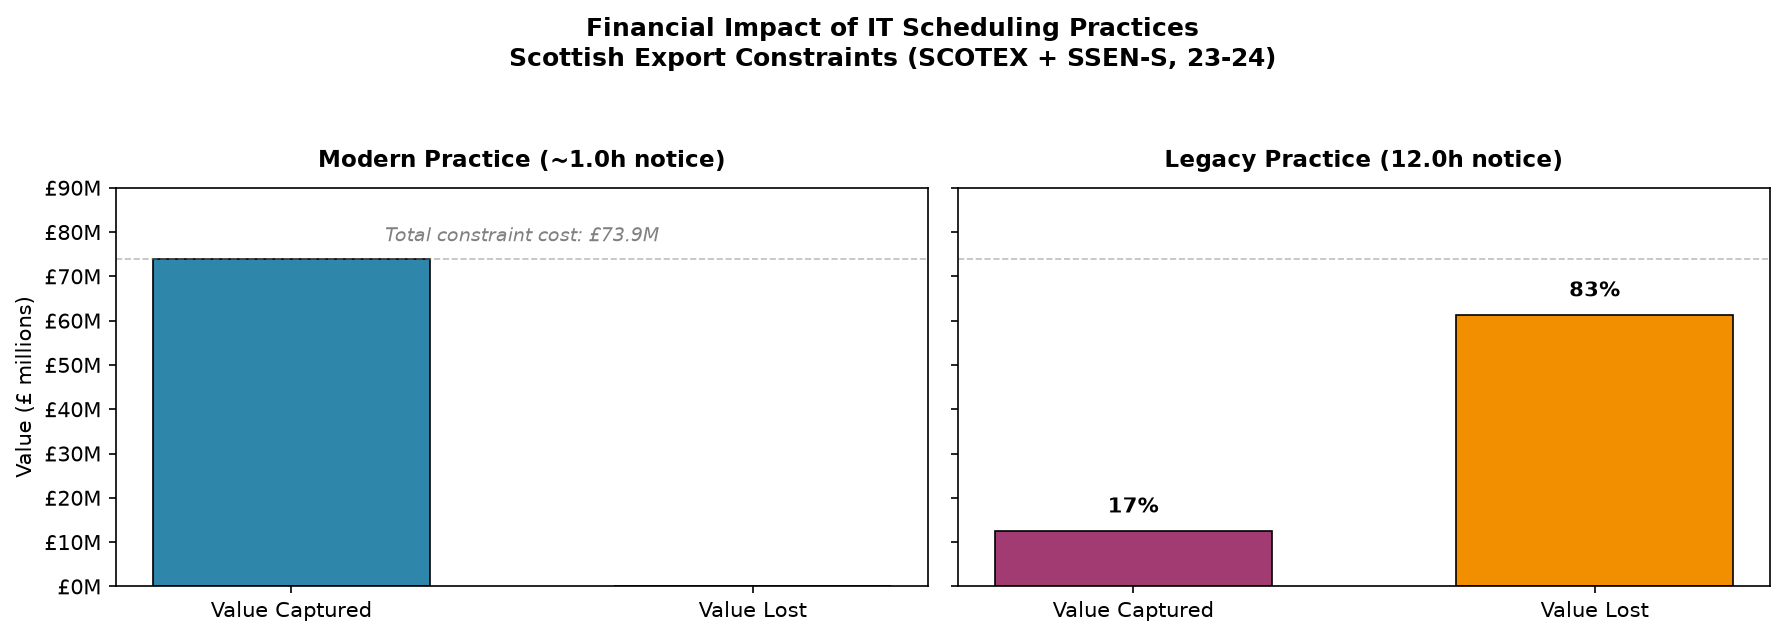

✅ Saved to: figures/04_value_captured_vs_lost.png


In [10]:
# =============================================================================
# Figure 1: Value Captured vs Value Lost (The Core Story)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Left panel: Modern Practice
axes[0].bar(['Value Captured', 'Value Lost'], 
            [value_captured_modern / 1e6, 0], 
            color=['#2E86AB', '#E8E8E8'], 
            edgecolor='black', linewidth=0.8, width=0.6)
axes[0].set_title('Modern Practice (~1.0h notice)', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Value (£ millions)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:.0f}M'))
axes[0].set_ylim(0, 90)  # Increased headroom to prevent title overlap
axes[0].axhline(y=total_cost_gbp/1e6, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].text(0.5, total_cost_gbp/1e6 + 3, f'Total constraint cost: £{total_cost_gbp/1e6:.1f}M', 
             ha='center', va='bottom', fontsize=9, style='italic', color='gray')

# Right panel: Legacy Practice
axes[1].bar(['Value Captured', 'Value Lost'], 
            [value_captured_legacy / 1e6, value_lost_legacy / 1e6], 
            color=['#A23B72', '#F18F01'], 
            edgecolor='black', linewidth=0.8, width=0.6)
axes[1].set_title('Legacy Practice (12.0h notice)', fontsize=11, fontweight='bold', pad=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:.0f}M'))
axes[1].set_ylim(0, 90)  # Match left panel
axes[1].axhline(y=total_cost_gbp/1e6, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Add percentage labels
axes[1].text(0, value_captured_legacy/1e6 + 3, f'{(compatibility_legacy*100):.0f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].text(1, value_lost_legacy/1e6 + 3, f'{((1-compatibility_legacy)*100):.0f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Financial Impact of IT Scheduling Practices\nScottish Export Constraints (SCOTEX + SSEN-S, 23-24)', 
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_value_captured_vs_lost.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to: {FIGURES_DIR / '04_value_captured_vs_lost.png'}")

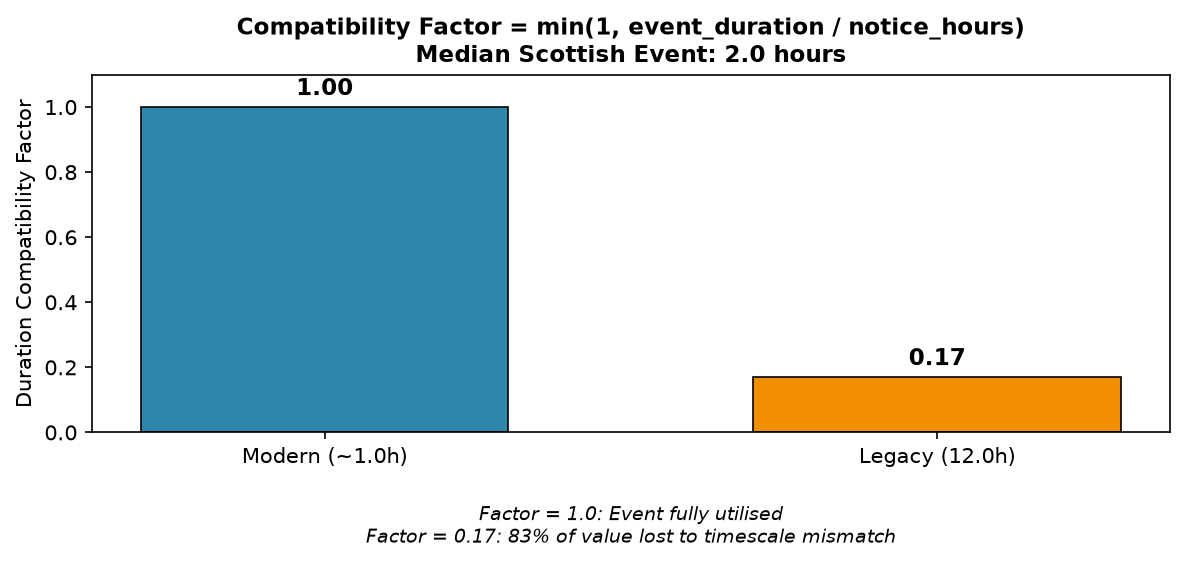

✅ Saved to: figures/04_compatibility_factor.png


In [17]:
# =============================================================================
# Figure 2: Duration Compatibility Factor (The Mechanism)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

practices = ['Modern (~1.0h)', 'Legacy (12.0h)']
factors = [compatibility_modern, compatibility_legacy]
colors = ['#2E86AB', '#F18F01']

bars = ax.bar(practices, factors, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
ax.set_ylabel('Duration Compatibility Factor', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Compatibility Factor = min(1, event_duration / notice_hours)\nMedian Scottish Event: 2.0 hours', 
             fontsize=11, fontweight='bold')

# Add value labels on bars
for bar, factor in zip(bars, factors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{factor:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add interpretation
ax.text(0.5, -0.20, 
        'Factor = 1.0: Event fully utilised\nFactor = 0.17: 83% of value lost to timescale mismatch', 
        ha='center', va='top', fontsize=9, style='italic', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_compatibility_factor.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to: {FIGURES_DIR / '04_compatibility_factor.png'}")

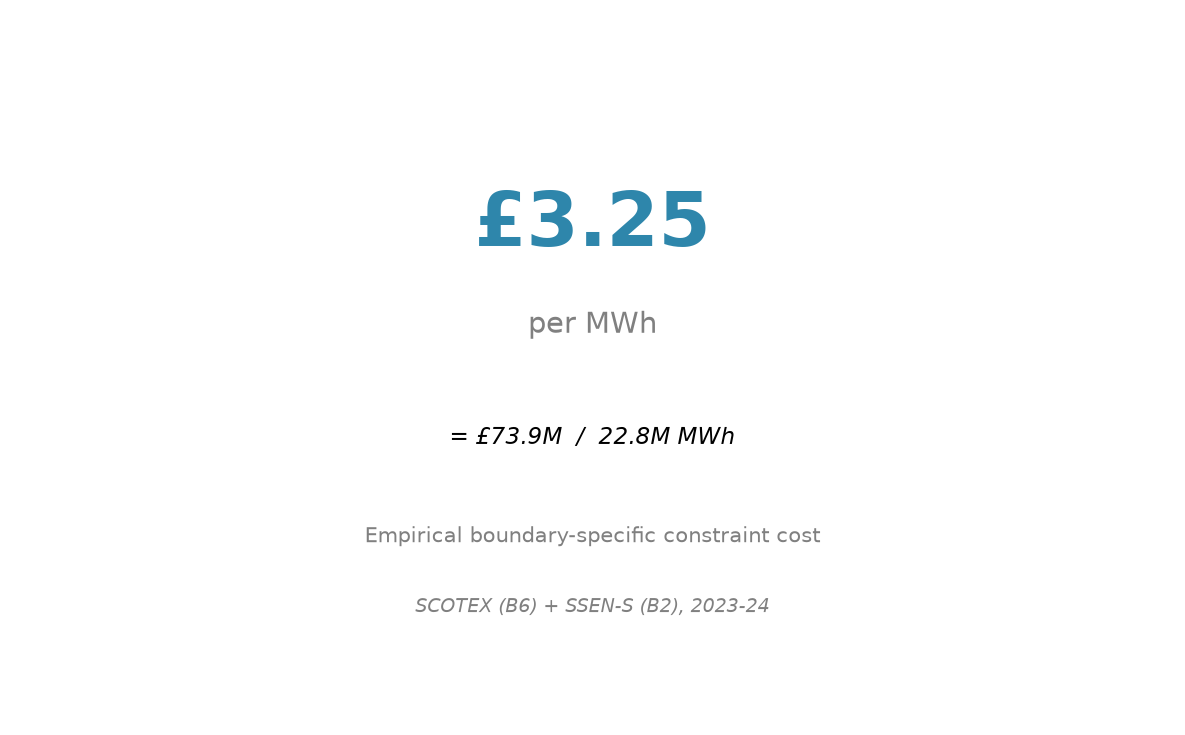

✅ Saved to: figures/04_cost_per_mwh_proxy.png


In [11]:
# =============================================================================
# Figure 3: Cost per MWh Breakdown (The Empirical Proxy)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Create a simple annotated box
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# Main value
ax.text(5, 3.5, f'£{empirical_gbp_per_mwh:.2f}', ha='center', va='center', 
        fontsize=36, fontweight='bold', color='#2E86AB')
ax.text(5, 2.8, 'per MWh', ha='center', va='center', 
        fontsize=14, color='gray')

# Formula
ax.text(5, 2.0, f'= £{total_cost_gbp/1e6:.1f}M  /  {total_volume_mwh/1e6:.1f}M MWh', 
        ha='center', va='center', fontsize=11, style='italic')

# Context
ax.text(5, 1.3, 'Empirical boundary-specific constraint cost', 
        ha='center', va='center', fontsize=10, color='gray')
ax.text(5, 0.8, 'SCOTEX (B6) + SSEN-S (B2), 2023-24', 
        ha='center', va='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_cost_per_mwh_proxy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to: {FIGURES_DIR / '04_cost_per_mwh_proxy.png'}")

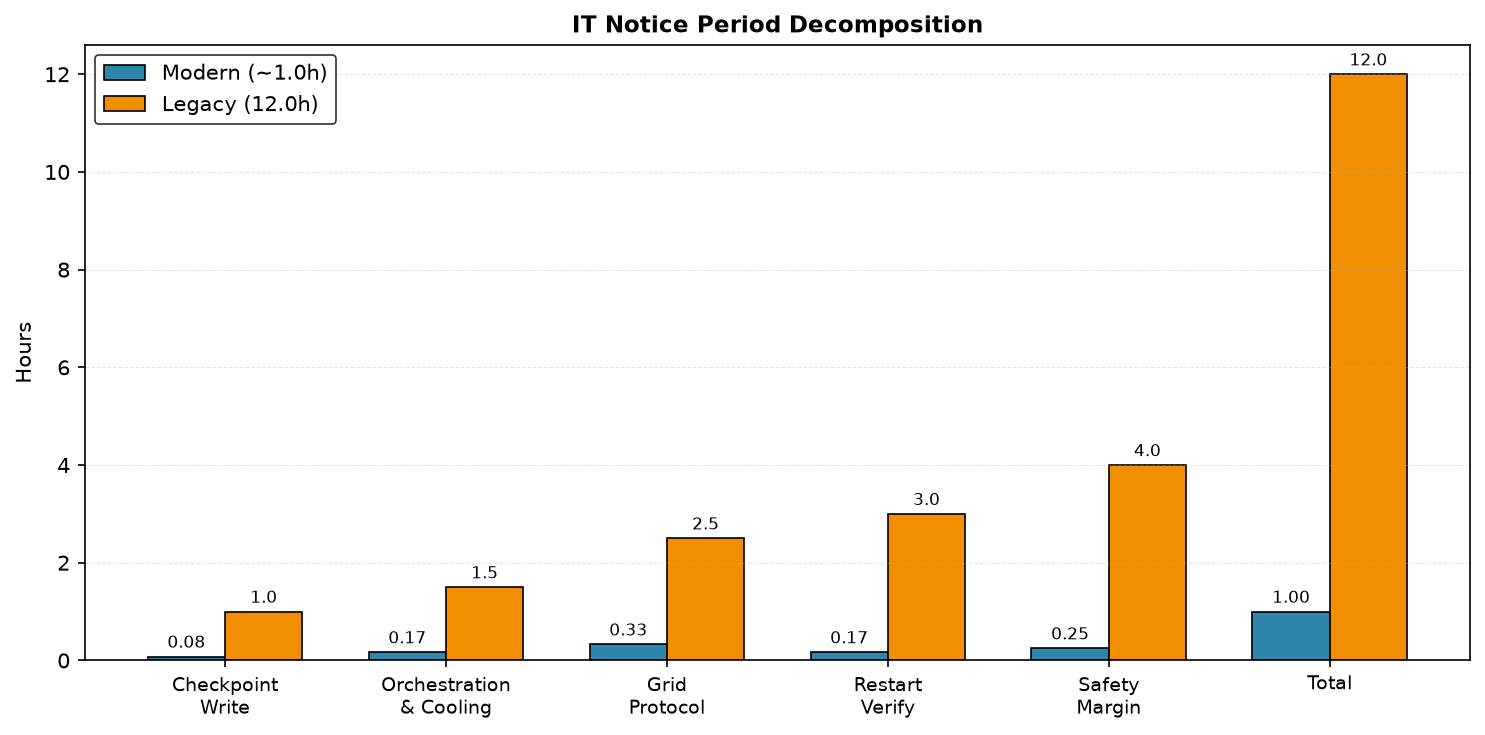

✅ Saved to: figures/04_it_notice_decomposition.png


In [12]:
# =============================================================================
# Figure 4: IT Notice Decomposition (The Physical Mechanism)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Modern practice breakdown (hours)
stages = ['Checkpoint\nWrite', 'Orchestration\n& Cooling', 'Grid\nProtocol', 
          'Restart\nVerify', 'Safety\nMargin', 'Total']
modern_hours = [0.08, 0.17, 0.33, 0.17, 0.25, 1.0]
legacy_hours = [1.0, 1.5, 2.5, 3.0, 4.0, 12.0]

x = np.arange(len(stages))
width = 0.35

bars1 = ax.bar(x - width/2, modern_hours, width, label='Modern (~1.0h)', 
               color='#2E86AB', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, legacy_hours, width, label='Legacy (12.0h)', 
               color='#F18F01', edgecolor='black', linewidth=0.8)

ax.set_ylabel('Hours', fontsize=10)
ax.set_title('IT Notice Period Decomposition', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=9)
ax.legend(loc='upper left', frameon=True, edgecolor='black', linewidth=0.8)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.5)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_it_notice_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved to: {FIGURES_DIR / '04_it_notice_decomposition.png'}")